# 02 — Hedonic Price Modeling

**Goal**: Estimate the fair market value of a home from its physical attributes
and neighbourhood-level Census socioeconomics (a *hedonic pricing model*).

### Statistical methodology
| Step | Detail |
|------|--------|
| **Train / test split** | 80 / 20 stratified by county, held-out test set touched only once |
| **Feature selection** | Property attributes + Census ACS rates; `pct_white` excluded (Fair Housing Act) |
| **Cross-validation** | 5-fold CV on the *training* set for model comparison |
| **Hyperparameter tuning** | Optuna Bayesian search (LightGBM) within CV folds |
| **Final evaluation** | Best model re-fit on full train set, scored on held-out test |
| **Reproducibility** | `SEED = 51` everywhere |

### Key assumptions
1. Sold prices in the past 12 months are representative of current market conditions.
2. Census ACS 5-year estimates are stable proxies for neighbourhood quality.
3. The hedonic framework assumes home price decomposes additively into contributions
   from individual attributes — plausible for the suburban Philly market but may
   under-weight hyper-local effects (school catchment, block-level desirability).
4. The filtered model (SFR, Del+Mont, $300k–$750k) intentionally sacrifices breadth
   for lower MAE within the user's target segment.

**Inputs**: `data/redfin_with_census.csv`  
**Outputs**: `models/hedonic_model.joblib`, `models/hedonic_model_filtered.joblib`, `data/model_results.csv`, `data/model_results_filtered.csv`

In [8]:
# ---------------------------------------------------------------------------
# Imports & global config
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os
import joblib
import warnings
import logging

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.model_selection import (
    cross_val_score,
    cross_val_predict,
    KFold,
    train_test_split,
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── Paths ────────────────────────────────────────────────────────────────────
JOINED_CSV           = "data/redfin_with_census.csv"
MODEL_FILE           = "models/hedonic_model.joblib"
FILTERED_MODEL_FILE  = "models/hedonic_model_filtered.joblib"
RESULTS_CSV          = "data/model_results.csv"
FILTERED_RESULTS_CSV = "data/model_results_filtered.csv"

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 51
np.random.seed(SEED)

print(f"Seed: {SEED}")

Seed: 51


In [9]:
# ---------------------------------------------------------------------------
# Load data & feature engineering
# ---------------------------------------------------------------------------
df = pd.read_csv(JOINED_CSV, low_memory=False)
df = df.loc[:, ~df.columns.duplicated()]
log.info(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

TARGET    = "PRICE"
BASE_YEAR = 2026

# Filter to sold listings only — removes Active/Pre On-Market listings
# whose PRICE is a list price, not a sale price
if "STATUS" in df.columns:
    before = len(df)
    df = df[df["STATUS"] == "Sold"].copy()
    log.info(f"Filtered to sold only: {len(df):,} rows (removed {before - len(df):,} non-sold)")

# ── Engineered features ──────────────────────────────────────────────────────
df["home_age"]       = BASE_YEAR - df["YEAR_BUILT"]
df["bath_bed_ratio"] = df["BATHS"] / df["BEDS"].replace(0, np.nan)
df["sqft_per_bed"]   = df["SQUARE_FEET"] / df["BEDS"].replace(0, np.nan)
df["log_sqft"]       = np.log1p(df["SQUARE_FEET"])
df["log_lot_size"]   = np.log1p(df["LOT_SIZE"])

# Log age: captures diminishing impact — going from 5→15 yrs matters more than 85→95
df["log_home_age"]   = np.log1p(df["home_age"])

# Density: sqft relative to lot size — proxy for how land-constrained the home is
df["sqft_per_lot"]   = df["SQUARE_FEET"] / df["LOT_SIZE"].replace(0, np.nan)

# Pre-war flag: many Philly-suburb homes built pre-1940 have distinct characteristics
# (plaster walls, older systems, charm premium vs. deferred maintenance penalty)
df["is_historic"]    = (df["YEAR_BUILT"] < 1940).astype(int)

# Temporal trend — captures within-sample market appreciation
df["SOLD_DATE"] = pd.to_datetime(df["SOLD_DATE"], errors="coerce")
BASE_DATE = pd.Timestamp("2024-01-01")
df["months_since_base"] = ((df["SOLD_DATE"] - BASE_DATE).dt.days / 30.44).clip(lower=0)

# Affordability index: neighbourhood income relative to home size
# High value → wealthy neighbourhood with smaller homes (premium location)
# Computed after census merge so median_household_income is available
df["income_sqft_idx"] = df["median_household_income"] / df["SQUARE_FEET"].replace(0, np.nan)

# ── Feature groups ───────────────────────────────────────────────────────────
META_COLS = ["ADDRESS", "CITY", "zip", "SOLD_DATE", "LATITUDE", "LONGITUDE"]

PROPERTY_FEATURES = [
    "BATHS", "SQUARE_FEET", "LOT_SIZE", "home_age",
    "bath_bed_ratio", "sqft_per_bed", "log_sqft", "log_lot_size",
    "months_since_base",
    "log_home_age",    # log-transformed age (non-linear age effects)
    "sqft_per_lot",    # density: how built-up is the lot
    "is_historic",     # pre-1940 construction flag
]

# NOTE: pct_white intentionally excluded — using race as a pricing input
# violates the spirit of the Fair Housing Act, even in a descriptive model.
#
# mean_commute_time = ACS B08303_001E (aggregate worker travel time in the ZCTA).
# Higher value → more suburban / car-dependent area → generally lower prices.
# Functions as a walkability/urbanity proxy without requiring a separate API.
CENSUS_FEATURES = [
    "median_household_income", "median_home_value", "median_gross_rent",
    "population", "median_year_built_neighborhood", "mean_commute_time",
    "vacancy_rate", "pct_bachelors_plus",
    "poverty_rate", "homeownership_rate",
    "income_sqft_idx",  # neighbourhood income per sqft of home (luxury index)
]

CATEGORICAL_FULL     = ["PROPERTY_TYPE", "COUNTY"]
CATEGORICAL_FILTERED = ["PROPERTY_TYPE"]


def build_model_df(source_df, categorical_features):
    """One-hot encode categoricals, drop nulls on target, median-impute features."""
    all_feats   = PROPERTY_FEATURES + CENSUS_FEATURES + categorical_features
    cols_needed = [TARGET] + all_feats + [c for c in META_COLS if c in source_df.columns]
    cols_present = [c for c in cols_needed if c in source_df.columns]
    mdf = source_df[cols_present].copy()
    mdf = pd.get_dummies(mdf, columns=categorical_features, drop_first=True)
    mdf = mdf.dropna(subset=[TARGET])
    feat_cols = [c for c in mdf.columns if c not in [TARGET] + META_COLS]
    for col in feat_cols:
        if mdf[col].isna().any():
            mdf[col] = mdf[col].fillna(mdf[col].median())
    return mdf, feat_cols


# ── Full dataset ─────────────────────────────────────────────────────────────
model_df, feature_cols = build_model_df(df, CATEGORICAL_FULL)
log.info(f"Full modelling set: {model_df.shape[0]:,} × {len(feature_cols)} features")

# ── Filtered dataset (user's target segment) ─────────────────────────────────
FILTER_COUNTIES  = ["Delaware County", "Montgomery County"]
FILTER_TYPES     = ["Single Family Residential"]
FILTER_PRICE_MIN = 300_000
FILTER_PRICE_MAX = 750_000

df_filtered = df[
    df["COUNTY"].isin(FILTER_COUNTIES)
    & df["PROPERTY_TYPE"].isin(FILTER_TYPES)
    & df["PRICE"].between(FILTER_PRICE_MIN, FILTER_PRICE_MAX)
].copy()

log.info(f"Filtered segment: {len(df_filtered):,} rows ({len(df_filtered)/len(df)*100:.1f}%)")

model_df_f, feature_cols_f = build_model_df(df_filtered, CATEGORICAL_FILTERED)
log.info(f"Filtered modelling set: {model_df_f.shape[0]:,} × {len(feature_cols_f)} features")

print(f"Full:     {model_df.shape[0]:,} rows, {len(feature_cols)} features")
print(f"Filtered: {model_df_f.shape[0]:,} rows, {len(feature_cols_f)} features")

2026-04-07 23:28:12,038 INFO Loaded 23,754 rows, 39 columns
2026-04-07 23:28:12,043 INFO Filtered to sold only: 23,754 rows (removed 0 non-sold)
2026-04-07 23:28:12,075 INFO Full modelling set: 23,754 × 29 features
2026-04-07 23:28:12,079 INFO Filtered segment: 5,078 rows (21.4%)
2026-04-07 23:28:12,084 INFO Filtered modelling set: 5,078 × 23 features


Full:     23,754 rows, 29 features
Filtered: 5,078 rows, 23 features


In [10]:
# ---------------------------------------------------------------------------
# Train / Test split — 80/20, stratified by county
# ---------------------------------------------------------------------------

# Full dataset
X_full = model_df[feature_cols]
y_full = model_df[TARGET]

# Stratify by county where possible
strat_col = next((c for c in model_df.columns if c.startswith("COUNTY_")), None)
strat = model_df[strat_col] if strat_col else None

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=SEED, stratify=strat,
)
log.info(f"Full — train: {len(X_train):,}  test: {len(X_test):,}")

# Filtered dataset
X_full_f = model_df_f[feature_cols_f]
y_full_f = model_df_f[TARGET]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full_f, y_full_f, test_size=0.20, random_state=SEED,
)
log.info(f"Filtered — train: {len(X_train_f):,}  test: {len(X_test_f):,}")

print("Splits created.  Test sets are held out until final evaluation.")

2026-04-07 23:28:12,119 INFO Full — train: 19,003  test: 4,751
2026-04-07 23:28:12,124 INFO Filtered — train: 4,062  test: 1,016


Splits created.  Test sets are held out until final evaluation.


In [11]:
# ---------------------------------------------------------------------------
# Model comparison — 5-fold CV on the TRAINING set only
# ---------------------------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)


def make_models(tuned_params=None):
    """Return a dict of candidate models."""
    lgbm_params = tuned_params or {
        "n_estimators": 500, "max_depth": 6, "learning_rate": 0.05,
        "subsample": 0.8, "colsample_bytree": 0.8,
        "min_child_samples": 20, "reg_alpha": 1.0, "reg_lambda": 1.0,
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }

    stacker = StackingRegressor(
        estimators=[
            ("lgbm", LGBMRegressor(**lgbm_params)),
            ("rf", RandomForestRegressor(
                n_estimators=200, max_depth=12,
                min_samples_leaf=5, random_state=SEED,
            )),
        ],
        final_estimator=Ridge(alpha=10),
        cv=5, n_jobs=-1,
    )

    return {
        "OLS Linear":        LinearRegression(),
        "Ridge":             Ridge(alpha=10),
        "Random Forest":     RandomForestRegressor(
            n_estimators=200, max_depth=12,
            min_samples_leaf=5, random_state=SEED, n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=300, max_depth=5,
            learning_rate=0.05, random_state=SEED,
        ),
        "LightGBM":          LGBMRegressor(**lgbm_params),
        "Stacking Ensemble": stacker,
    }


def run_cv_comparison(X_in, y_in, label):
    models = make_models()
    print(f"\n{'=' * 70}")
    print(f"5-FOLD CV ON TRAINING SET — {label}")
    print(f"{'=' * 70}")
    print(f"{'Model':<22} {'R² mean':>9} {'R² std':>8} {'MAE mean':>14} {'RMSE mean':>14}")
    print("-" * 70)
    results = {}
    for name, model in models.items():
        r2  = cross_val_score(model, X_in, y_in, cv=kf, scoring="r2", n_jobs=-1)
        mae = cross_val_score(model, X_in, y_in, cv=kf,
                              scoring="neg_mean_absolute_error", n_jobs=-1)
        rmse = cross_val_score(model, X_in, y_in, cv=kf,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
        results[name] = {
            "r2_mean": r2.mean(), "r2_std": r2.std(),
            "mae_mean": -mae.mean(), "rmse_mean": -rmse.mean(),
        }
        print(f"{name:<22} {r2.mean():>9.4f} {r2.std():>8.4f} "
              f"${-mae.mean():>12,.0f} ${-rmse.mean():>12,.0f}")
    print("=" * 70)
    best = max(results, key=lambda k: results[k]["r2_mean"])
    print(f"Best: {best}  (R²={results[best]['r2_mean']:.4f}, "
          f"MAE=${results[best]['mae_mean']:,.0f})")
    return results, best


results_full, _  = run_cv_comparison(X_train, y_train, "FULL DATASET")
results_filt, _  = run_cv_comparison(X_train_f, y_train_f,
                                     "FILTERED: SFR, Del+Mont, $300k-$750k")


5-FOLD CV ON TRAINING SET — FULL DATASET
Model                    R² mean   R² std       MAE mean      RMSE mean
----------------------------------------------------------------------


OLS Linear              -14.8530  31.2320 $      84,345 $     489,894
Ridge                   -14.5940  30.7135 $      84,314 $     486,605
Random Forest             0.8346   0.0092 $      64,361 $      92,050
Gradient Boosting         0.8470   0.0052 $      62,591 $      88,569
LightGBM                  0.8560   0.0074 $      60,350 $      85,903
Stacking Ensemble         0.8564   0.0075 $      60,283 $      85,795
Best: Stacking Ensemble  (R²=0.8564, MAE=$60,283)

5-FOLD CV ON TRAINING SET — FILTERED: SFR, Del+Mont, $300k-$750k
Model                    R² mean   R² std       MAE mean      RMSE mean
----------------------------------------------------------------------
OLS Linear                0.6301   0.0231 $      55,755 $      72,710
Ridge                     0.6210   0.0179 $      56,141 $      73,610
Random Forest             0.6592   0.0206 $      53,320 $      69,797
Gradient Boosting         0.6819   0.0257 $      51,084 $      67,405
LightGBM                  0.6794   0.0275

2026-04-07 23:35:33,737 INFO Running Optuna — 80 trials on filtered training set...


  0%|          | 0/80 [00:00<?, ?it/s]


Best CV MAE: $50,309

Tuned parameters:
  n_estimators: 943
  max_depth: 6
  learning_rate: 0.01171358833995457
  subsample: 0.8953026943034392
  colsample_bytree: 0.5431917054249098
  min_child_samples: 5
  reg_alpha: 0.000287686548998281
  reg_lambda: 3.3013618286304602
  random_state: 51
  n_jobs: -1
  verbose: -1


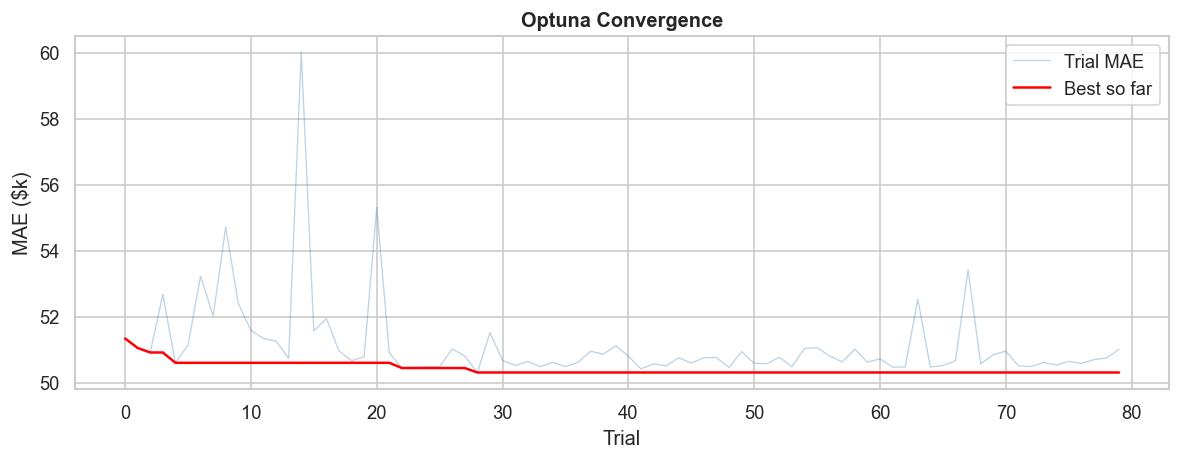

In [12]:
# ---------------------------------------------------------------------------
# Optuna hyperparameter tuning — LightGBM on filtered TRAIN set
# ---------------------------------------------------------------------------


def optuna_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1200),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }
    model  = LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_train_f, y_train_f, cv=kf,
        scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    return -scores.mean()


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
log.info("Running Optuna — 80 trials on filtered training set...")
study.optimize(optuna_objective, n_trials=80, show_progress_bar=True)

best_params = {**study.best_params, "random_state": SEED, "n_jobs": -1, "verbose": -1}
print(f"\nBest CV MAE: ${study.best_value:,.0f}")
print("\nTuned parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Tuning convergence plot
trials_df = study.trials_dataframe()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_df["number"], trials_df["value"] / 1000,
        alpha=0.35, color="steelblue", lw=0.8, label="Trial MAE")
ax.plot(trials_df["number"], trials_df["value"].cummin() / 1000,
        color="red", lw=1.5, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("MAE ($k)")
ax.set_title("Optuna Convergence", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plots/optuna_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# ---------------------------------------------------------------------------
# Fit best models on full TRAINING set, evaluate on HELD-OUT test
# ---------------------------------------------------------------------------
from sklearn.linear_model import LinearRegression as LR

# ── Filtered model (tuned LightGBM) ─────────────────────────────────────────
best_lgbm_f = LGBMRegressor(**best_params)
best_lgbm_f.fit(X_train_f, y_train_f)

y_pred_test_f = best_lgbm_f.predict(X_test_f)
test_r2_f   = r2_score(y_test_f, y_pred_test_f)
test_mae_f  = mean_absolute_error(y_test_f, y_pred_test_f)
test_rmse_f = np.sqrt(mean_squared_error(y_test_f, y_pred_test_f))

print("=" * 55)
print("FILTERED MODEL — HELD-OUT TEST SET")
print("=" * 55)
print(f"  R²:   {test_r2_f:.4f}")
print(f"  MAE:  ${test_mae_f:,.0f}")
print(f"  RMSE: ${test_rmse_f:,.0f}")

# Re-fit on ALL filtered data for production use
best_lgbm_f_prod = LGBMRegressor(**best_params)
best_lgbm_f_prod.fit(X_full_f, y_full_f)

# Compute residual stats from CV predictions (unbiased, no data leakage)
cv_preds_f   = cross_val_predict(best_lgbm_f_prod, X_full_f, y_full_f, cv=kf, n_jobs=-1)
cv_residuals = y_full_f.values - cv_preds_f
residual_std_f  = np.std(cv_residuals)
residual_mean_f = np.mean(cv_residuals)

# ── Appreciation: residualized regression ────────────────────────────────────
# Problem with simple OLS on months_since_base: it doesn't control for home
# characteristics, so it conflates composition effects ("cheaper homes sold later")
# with actual market price change.
#
# Fix: residualize. Explain price with all features EXCEPT the time variable,
# then regress the unexplained portion on months_since_base. This isolates the
# pure temporal trend controlling for property mix.
_feats_no_time = [f for f in feature_cols_f if f != "months_since_base"]
_X_no_time = X_full_f[_feats_no_time].fillna(X_full_f[_feats_no_time].median())
_ridge_no_time = Ridge(alpha=10).fit(_X_no_time, y_full_f)
_resid_no_time = y_full_f.values - _ridge_no_time.predict(_X_no_time)
_lr_time = LR().fit(X_full_f[["months_since_base"]], _resid_no_time)
monthly_appreciation = _lr_time.coef_[0]
annual_appreciation_pct = (monthly_appreciation * 12) / y_full_f.median() * 100

print(f"\n  CV residual σ:  ${residual_std_f:,.0f}")
print(f"  Monthly trend (residualized): ${monthly_appreciation:,.0f}/mo  "
      f"(~{annual_appreciation_pct:.1f}% annualised at median price)")
if annual_appreciation_pct < 0:
    print(f"\n  NOTE: Negative data-driven trend in this segment/window.")
    print(f"  The dashboard provides a manual appreciation slider to override this.")

joblib.dump({
    "model":                  best_lgbm_f_prod,
    "feature_cols":           feature_cols_f,
    "residual_std":           residual_std_f,
    "residual_mean":          residual_mean_f,
    "monthly_appreciation":   monthly_appreciation,
    "annual_appreciation_pct": annual_appreciation_pct,
    "test_r2":  test_r2_f,
    "test_mae": test_mae_f,
    "seed": SEED,
}, FILTERED_MODEL_FILE)
log.info(f"Saved → {FILTERED_MODEL_FILE}")

# Save results for evaluation notebook
res_f = model_df_f[[c for c in META_COLS if c in model_df_f.columns] + [TARGET]].copy()
res_f["predicted"]    = best_lgbm_f_prod.predict(X_full_f)
res_f["residual"]     = res_f[TARGET] - res_f["predicted"]
res_f["pct_error"]    = res_f["residual"] / res_f[TARGET] * 100
res_f["cv_predicted"] = cv_preds_f
res_f.to_csv(FILTERED_RESULTS_CSV, index=False)

# ── Full model ───────────────────────────────────────────────────────────────
full_params = {**best_params}
best_lgbm = LGBMRegressor(**full_params)
best_lgbm.fit(X_train, y_train)

y_pred_test = best_lgbm.predict(X_test)
test_r2   = r2_score(y_test, y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\n{'=' * 55}")
print("FULL MODEL — HELD-OUT TEST SET")
print("=" * 55)
print(f"  R²:   {test_r2:.4f}")
print(f"  MAE:  ${test_mae:,.0f}")
print(f"  RMSE: ${test_rmse:,.0f}")

best_lgbm_prod = LGBMRegressor(**full_params)
best_lgbm_prod.fit(X_full, y_full)

cv_preds_full  = cross_val_predict(best_lgbm_prod, X_full, y_full, cv=kf, n_jobs=-1)
residual_std   = np.std(y_full.values - cv_preds_full)

joblib.dump({
    "model":        best_lgbm_prod,
    "feature_cols": feature_cols,
    "residual_std": residual_std,
    "test_r2":  test_r2,
    "test_mae": test_mae,
    "seed": SEED,
}, MODEL_FILE)
log.info(f"Saved → {MODEL_FILE}")

res = model_df[[c for c in META_COLS if c in model_df.columns] + [TARGET]].copy()
res["predicted"]    = best_lgbm_prod.predict(X_full)
res["residual"]     = res[TARGET] - res["predicted"]
res["pct_error"]    = res["residual"] / res[TARGET] * 100
res["cv_predicted"] = cv_preds_full
res.to_csv(RESULTS_CSV, index=False)

print(f"\nAll artefacts saved to models/ and data/.")

FILTERED MODEL — HELD-OUT TEST SET
  R²:   0.7096
  MAE:  $48,118
  RMSE: $64,231


2026-04-07 23:43:29,167 INFO Saved → models/hedonic_model_filtered.joblib



  CV residual σ:  $65,989
  Monthly trend (residualized): $-1,167/mo  (~-2.9% annualised at median price)

  NOTE: Negative data-driven trend in this segment/window.
  The dashboard provides a manual appreciation slider to override this.

FULL MODEL — HELD-OUT TEST SET
  R²:   0.8518
  MAE:  $60,767
  RMSE: $86,817


2026-04-07 23:43:45,996 INFO Saved → models/hedonic_model.joblib



All artefacts saved to models/ and data/.


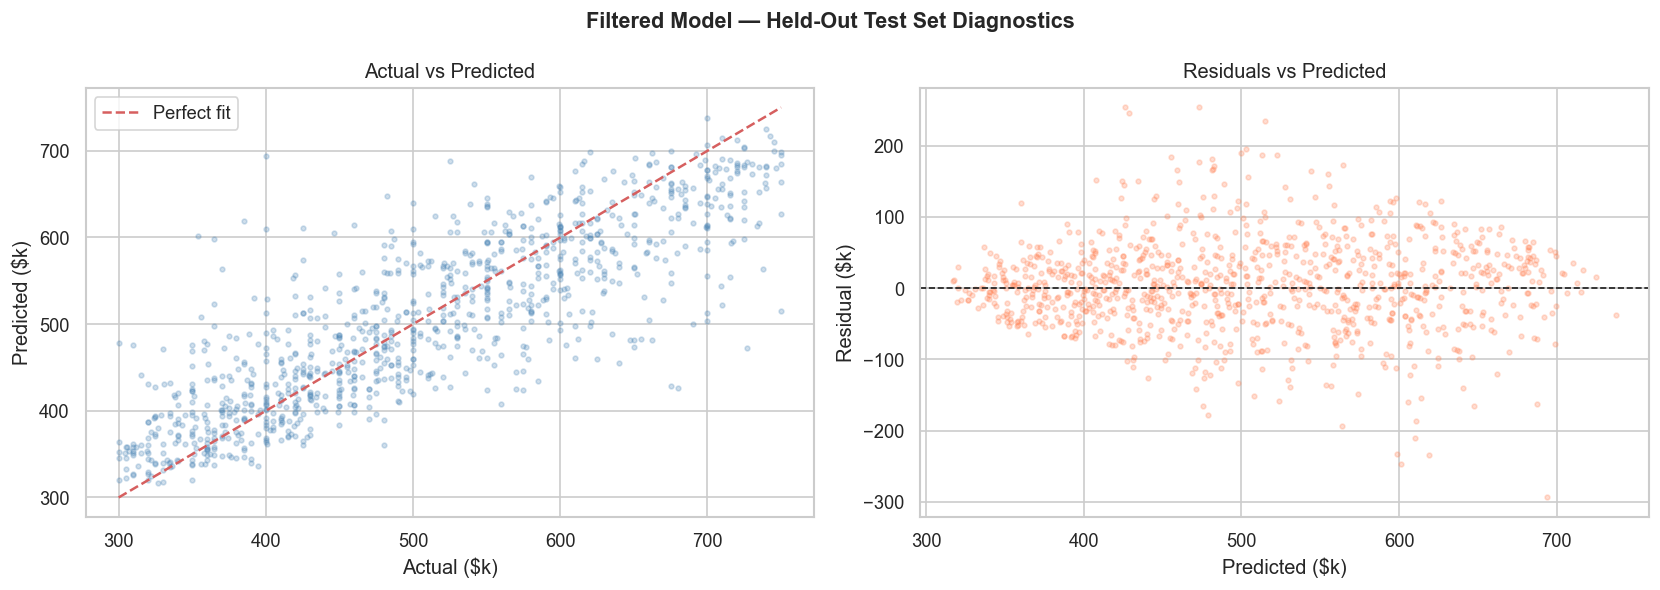

See 03_evaluation.ipynb for full evaluation, geographic analysis, and offer logic.


In [14]:
# ---------------------------------------------------------------------------
# Quick diagnostic — filtered model
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Filtered Model — Held-Out Test Set Diagnostics", fontsize=13, fontweight="bold")

axes[0].scatter(y_test_f / 1e3, y_pred_test_f / 1e3, alpha=0.25, s=8, c="steelblue")
lims = [min(y_test_f.min(), y_pred_test_f.min()) / 1e3,
        max(y_test_f.max(), y_pred_test_f.max()) / 1e3]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual ($k)")
axes[0].set_ylabel("Predicted ($k)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

resid_test = y_test_f.values - y_pred_test_f
axes[1].scatter(y_pred_test_f / 1e3, resid_test / 1e3, alpha=0.25, s=8, c="coral")
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Predicted ($k)")
axes[1].set_ylabel("Residual ($k)")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.savefig("plots/filtered_model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print("See 03_evaluation.ipynb for full evaluation, geographic analysis, and offer logic.")